# Velocity from gravity-free acceleration

This is the final goal of the pipeline. 

Velocity/speed satisfies the following equation:
$$
\frac{d\mathbf{v}}{dt} = \mathbf{a}(t)
$$
One could try to view this problem in two (related) ways: as ODE (ordinary differential equation) or as an integration problem. 

Viewing it as an ODE, there are some issues. Most (if not all) methods (Runge-Kutta, multistep) assume an available function of the independent and dependent variables that can be evaluated at different places. This isn't my case: I only have measurements, and I don't have a physical models of calisthenics exercises either. Trying to apply ODE methods anyway would necessarily need some form of curve fitting (e.g. regression, splines) prior to actually running the ODE method itself. This is obviously not viable for a device that has to run real-time on constrainted resources.   

Viewing it as an integration problem, applying the fundamental theorem of calculus, we have:

$$
\int_{t_i}^{t_i+1} d\mathbf{v} = \int_{t_i}^{t_i+1} \mathbf{a}(t) dt \newline

v_{x, t_i+1} = v_{x, t_i} + \int_{t_i}^{t_i+1} a_x(t) dt \newline
v_{y, t_i+1} = v_{y, t_i} + \int_{t_i}^{t_i+1} a_y(t) dt \newline
v_{z, t_i+1} = v_{z, t_i} + \int_{t_i}^{t_i+1} a_z(t) dt \newline
$$
This is a much simpler problem, since for $a(t)$ I can just apply well-known numerical integration formulas (Newton-Cotes, Adams-Moulton). To determine the best one, I'll run a series of tests: solving a simple ODE with known solution, solving the same ODE with a known solution but with added noise, and finally solving the actual problem of velocity from acceleration. The best method is the one that gives the best results with least computational cost.

Sources:
* [Numerical methods for engineers](../../docs/misc/Numerical%20Methods%20for%20Engineers%20(7ed)%20-%20Chapra,%20Canale.pdf). Chapters 21, 25, 26.

## Setup

In [23]:
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt


def computeErrors(y, trueValues, estimatedValues):
    errors = trueValues - estimatedValues
    absCumulativeErrors = np.abs(np.cumsum(errors)) + 1e-12
    rmse = np.sqrt(np.mean(errors**2))
    return (errors, absCumulativeErrors, rmse)


# Follow signature from scipy methods
def cumulative_euler(dy, x, dx):
    result = np.zeros_like(dy)
    for i in range(1, len(dy)):
        result[i] = result[i - 1] + dy[i - 1] * dx
    return result


def cumulative_closed_adams_3(dy, x, dx):
    result = np.zeros_like(dy)
    result[1] = (dy[0] + dy[1]) * dx / 2  # Trapezoid rule for the first step
    for i in range(2, len(dy)):
        result[i] = result[i - 1] + (dx / 12) * (5 * dy[i] + 8 * dy[i - 1] - dy[i - 2])
    return result

# Simple ODE with known solution
*Equation*: 
$\frac{dy}{dx} = -2x^3 + 12x^2 -20x+8.5, \text{ with } y(0) = 1$

*Conclusion*: 
* Euler is just bad. It would only work well with very small step sizes and small integration windows. Don't use if possible.  
* The other ones tend to be cluster together: Simpson is better than Adams3, which in turn is better than Trapezium. 
* On the device, Simpson would need a different implementation. Samples come as a stream, and only one is processed at a time. The solution would need to be provided every two samples, and I would need to be careful of not integrating the same sample twice. Adams-Moulton formulas are a better fit, since they use previous points to fit a polynomial but only integrate on the last interval.
* Higher order polynomials are probably not worth it.

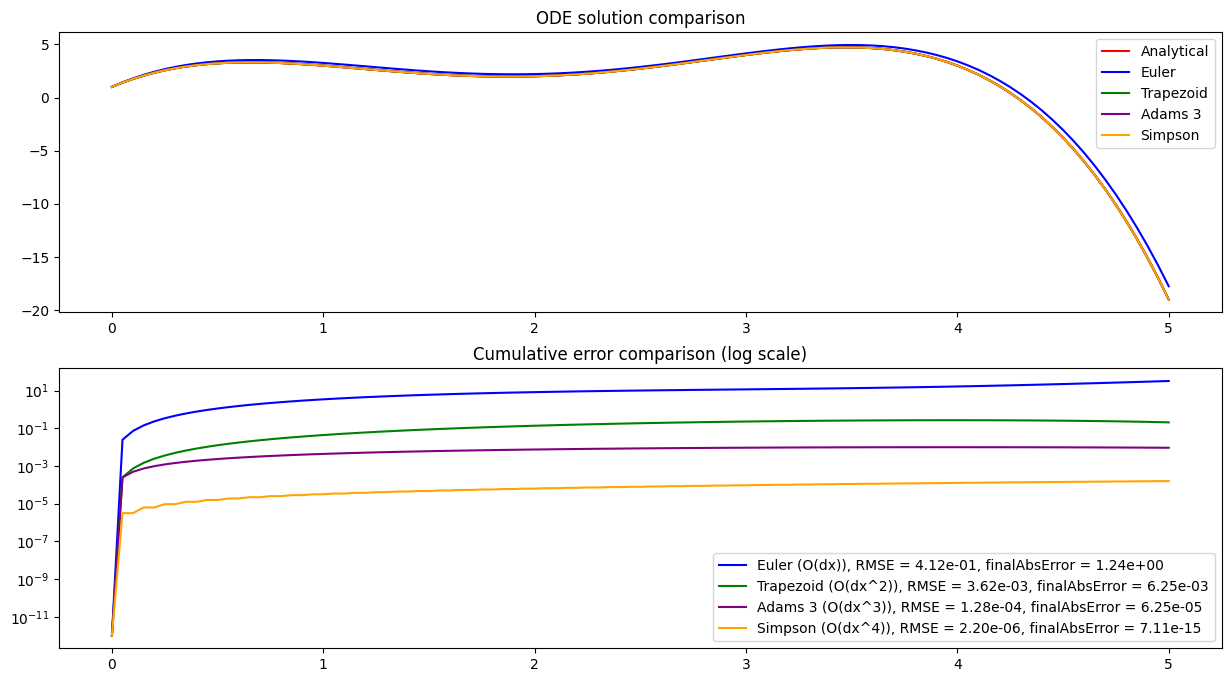

In [35]:
lowerBound = 0
upperBound = 5
dx = 0.05
x = np.arange(lowerBound, upperBound + dx, dx)
dy = -2 * x**3 + 12 * x**2 - 20 * x + 8.5
x0 = 0
y0 = 1

y = -0.5 * x**4 + 4 * x**3 - 10 * x**2 + 8.5 * x + 1

eulerSol = y0 + cumulative_euler(dy, x=x, dx=dx)
trapSol = y0 + integrate.cumulative_trapezoid(dy, x=x, dx=dx, initial=0)
adams3Sol = y0 + cumulative_closed_adams_3(dy, x=x, dx=dx)
simpsonSol = y0 + integrate.cumulative_simpson(dy, x=x, dx=dx, initial=0)

errorsEuler, absCumErrorsEuler, rmsEuler = computeErrors(y, y, eulerSol)
errorsTrap, absCumErrorsTrap, rmsTrap = computeErrors(y, y, trapSol)
errorsAdams3, absCumErrorsAdams3, rmsAdams3 = computeErrors(y, y, adams3Sol)
errorsSimpson, absCumErrorsSimpson, rmsSimpson = computeErrors(y, y, simpsonSol)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].set_title("ODE solution comparison")
axes[0].plot(x, y, label="Analytical", color="red")
axes[0].plot(x, eulerSol, label="Euler", color="blue")
axes[0].plot(x, trapSol, label="Trapezoid", color="green")
axes[0].plot(x, adams3Sol, label="Adams 3", color="purple")
axes[0].plot(x, simpsonSol, label="Simpson", color="orange")
axes[0].legend()

axes[1].set_title("Cumulative error comparison (log scale)")
axes[1].plot(
    x,
    absCumErrorsEuler,
    label=f"Euler (O(dx)), RMSE = {rmsEuler:.2e}, finalAbsError = {abs(errorsEuler[-1]):.2e}",
    color="blue",
)
axes[1].plot(
    x,
    absCumErrorsTrap,
    label=f"Trapezoid (O(dx^2)), RMSE = {rmsTrap:.2e}, finalAbsError = {abs(errorsTrap[-1]):.2e}",
    color="green",
)
axes[1].plot(
    x,
    absCumErrorsAdams3,
    label=f"Adams 3 (O(dx^3)), RMSE = {rmsAdams3:.2e}, finalAbsError = {abs(errorsAdams3[-1]):.2e}",
    color="purple",
)
axes[1].plot(
    x,
    absCumErrorsSimpson,
    label=f"Simpson (O(dx^4)), RMSE = {rmsSimpson:.2e}, finalAbsError = {abs(errorsSimpson[-1]):.2e}",
    color="orange",
)
axes[1].set_yscale("log")
axes[1].legend()

plt.show()